# 03 - HistGradientBoosting (sklearn boosted trees)

Third model in the lineup, **identical template to 01/02** (same roster,
same point-in-time split, same calibration + threshold logic) → fair
comparison in `05`. HistGradientBoosting is sklearn's histogram-based boosting
(LightGBM-style): fast, handles **NaN natively**, well interpretable.

Saves by convention → automatically recognized by `05` and the Dash app
(dropdown "HistGradientBoosting (03)"): `Data/03_histgb_model.joblib`,
`Data/03_histgb_predictions.parquet`,
`reports/tables/03_histgb/model_card.json` (+ `feature_importances_by_feature.csv`).

## §0 - Setup

In [ ]:
# =============================================================================
# §0 SETUP - Imports, paths, plot style (Plotly + matplotlib fallback for PDP/SHAP)
# =============================================================================
from __future__ import annotations
import sys, json, warnings
from pathlib import Path

# Find the project root so that `from src import ...` works.
_here = Path.cwd().resolve()
while not (_here / "pyproject.toml").exists():
    _here = _here.parent
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import (apply_stayery_style, color, load_clean_reservations, figures_dir, tables_dir)
from src import plotting as P                 # Plotly brand helpers (Dash-compatible)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
apply_stayery_style()                          # matplotlib style (PDP/SHAP PNGs)
P.apply_plotly_theme()                         # Plotly brand theme, global

FIG = figures_dir() / "03_histgb"; FIG.mkdir(parents=True, exist_ok=True)
TAB = tables_dir()  / "03_histgb"; TAB.mkdir(parents=True, exist_ok=True)

FAST_DEV = False                               # True = smaller/faster for tests
SEED = 42
print(f"Setup ok. Project: {_here.name} | FAST_DEV={FAST_DEV}")

Setup ok. Project: OverbookingAnalyse | FAST_DEV=False


## §1 - Load data

In [2]:
# =============================================================================
# §1 LOAD DATA  (identical to 01/02)
# =============================================================================
df = load_clean_reservations()                              # clean Parquet from 00
df = df.rename(columns={"status": "is_cancelled"})          # give the target a descriptive name
if FAST_DEV:
    df = df.iloc[::5].copy()                                # only every 5th row (fast)
print(f"{len(df):,} bookings | arrivals {df['arrival'].min().date()} .. {df['arrival'].max().date()}")
print(f"Overall cancellation rate: {df['is_cancelled'].mean():.1%}")

176,448 bookings | arrivals 2022-08-01 .. 2026-06-18
Overall cancellation rate: 19.6%


## §2 - Feature selection (from the roster)

In [ ]:
# =============================================================================
# §2 FEATURE LISTS - from the ROSTER (Data/feature_roster.json, 00 §11)
# =============================================================================
# IDENTICAL to 01/02: same roster -> fair comparison in 05.
from src import roster_features

NUM_FEATURES, CAT_FEATURES = roster_features()
NUM_HISTORY: list[str] = []                                 # company history excluded by roster
TARGET = "is_cancelled"

_missing = [c for c in NUM_FEATURES + NUM_HISTORY + CAT_FEATURES + [TARGET] if c not in df.columns]
assert not _missing, f"Missing columns (re-run 00?): {_missing}"

# Dtype hygiene: numeric -> float64 (NaN preserved -> HistGB native), categorical -> object.
for c in NUM_FEATURES + NUM_HISTORY:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("float64")
for c in CAT_FEATURES:
    df[c] = df[c].astype("object")
df[TARGET] = df[TARGET].astype("int64")
print(f"{len(NUM_FEATURES)} numeric + {len(CAT_FEATURES)} categorical features (roster).")

13 numeric + 7 categorical features (roster).


## §3 - Temporal split (train/val/test from 00)

In [ ]:
# =============================================================================
# §3 APPLY SPLIT  (identical to 01/02 - point-in-time split comes from 00)
# =============================================================================
m_train = df["temporal_split"] == "train"
m_val   = df["temporal_split"] == "val"
m_test  = df["temporal_split"] == "test"
# embargo rows (in-flight) are in no mask -> correctly dropped.

FEATURES = NUM_FEATURES + NUM_HISTORY + CAT_FEATURES
X_train, y_train = df.loc[m_train, FEATURES], df.loc[m_train, TARGET]
X_val,   y_val   = df.loc[m_val,   FEATURES], df.loc[m_val,   TARGET]
X_test,  y_test  = df.loc[m_test,  FEATURES], df.loc[m_test,  TARGET]

# Sort train chronologically (required for TimeSeriesSplit in §6).
_order  = df.loc[m_train, "arrival"].sort_values(kind="mergesort").index
X_train, y_train = X_train.loc[_order], y_train.loc[_order]

for name, m in [("train", m_train), ("val", m_val), ("test", m_test)]:
    sub = df.loc[m]
    print(f"{name:5s}: {m.sum():>7,} rows | cancellation {sub[TARGET].mean():.1%}")

train: 105,816 rows | cancellation 20.2%
val  :  27,038 rows | cancellation 16.6%
test :  35,290 rows | cancellation 17.5%


## §4 - Preprocessing (tree-friendly: OHE + numeric native)

In [ ]:
# =============================================================================
# §4 PREPROCESSOR - one-hot for categories, numeric unchanged (NaN preserved)
# =============================================================================
# IDENTICAL to 02 -> same model matrix -> fair comparison. HistGB handles
# NaN in the passthrough numeric columns natively (like XGBoost).
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

NUM_ALL = NUM_FEATURES + NUM_HISTORY
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_FEATURES),
    ("num", "passthrough", NUM_ALL),                                 # numbers 1:1 (NaN preserved)
])
_demo = preprocessor.fit_transform(X_train)
_arr = _demo.toarray() if hasattr(_demo, "toarray") else np.asarray(_demo)
print(f"From {len(FEATURES)} raw features we get {_arr.shape[1]} model columns (after one-hot).")

From 20 raw features we get 105 model columns (after one-hot).


## §5 - Model: HistGradientBoosting + calibration

In [6]:
# =============================================================================
# §5 DEFINE MODEL  (baseline; tuned in §6b)
# =============================================================================
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

# Fixed settings in ONE place. early_stopping uses an internal
# validation split so that max_iter is an upper bound (no overfit).
HGB_FIXED = dict(random_state=SEED, early_stopping=True,
                 validation_fraction=0.1, n_iter_no_change=20)
# Baseline hyperparameters (may be overridden in §6b).
BASE_PARAMS = dict(learning_rate=0.05, max_leaf_nodes=31, min_samples_leaf=40,
                   l2_regularization=1.0, max_iter=600)

base_hgb = HistGradientBoostingClassifier(**HGB_FIXED, **BASE_PARAMS)
# Calibration wrapper (like 01/02): isotonic correction over 5 internal folds.
calibrated = CalibratedClassifierCV(estimator=base_hgb, method="isotonic", cv=5)
model = Pipeline([("prep", preprocessor), ("clf", calibrated)])
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## §6 - Dual-CV on train (time vs. random = drift check)

In [7]:
# =============================================================================
# §6 DUAL-CV: TimeSeriesSplit (primary) vs StratifiedKFold (diagnostic)
# =============================================================================
from sklearn.model_selection import TimeSeriesSplit, StratifiedKFold, cross_validate

cv_pipeline = Pipeline([("prep", preprocessor),
                        ("clf", HistGradientBoostingClassifier(**HGB_FIXED, **BASE_PARAMS))])
n_folds = 3 if FAST_DEV else 5
tss = TimeSeriesSplit(n_splits=n_folds)
res_time = cross_validate(cv_pipeline, X_train, y_train, cv=tss,
                          scoring=["roc_auc", "average_precision"], n_jobs=-1)
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
res_rand = cross_validate(cv_pipeline, X_train, y_train, cv=skf,
                          scoring=["roc_auc", "average_precision"], n_jobs=-1)
cv_table = pd.DataFrame({
    "cv": ["TimeSeriesSplit (primary)", "StratifiedKFold (diagnostic)"],
    "auc_mean": [res_time["test_roc_auc"].mean(), res_rand["test_roc_auc"].mean()],
    "ap_mean":  [res_time["test_average_precision"].mean(), res_rand["test_average_precision"].mean()],
}).round(4)
cv_table.to_csv(TAB / "cv_dual.csv", index=False)
gap = res_rand["test_roc_auc"].mean() - res_time["test_roc_auc"].mean()
print(cv_table.to_string(index=False))
print(f"\nDrift check: random AUC - time AUC = {gap:+.4f} "
      f"({'OK' if abs(gap) <= 0.03 else 'WARNING: check drift/leakage'})")

                          cv  auc_mean  ap_mean
   TimeSeriesSplit (primary)    0.7944   0.5236
StratifiedKFold (diagnostic)    0.8189   0.5747

Drift check: random AUC - time AUC = +0.0244 (OK)


## §6b - Hyperparameter search (time-CV, metric = AP) + selection

In [8]:
# =============================================================================
# §6b RANDOMIZED SEARCH (train-only, TimeSeriesSplit) + baseline-vs-tuned on val
# =============================================================================
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone
from scipy.stats import loguniform, randint
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

# Search on the UNcalibrated pipeline (calibration does not change the ranking).
search_pipe = Pipeline([("prep", clone(preprocessor)),
                        ("clf", HistGradientBoostingClassifier(**HGB_FIXED))])
space = {
    "clf__learning_rate":    loguniform(0.01, 0.3),
    "clf__max_leaf_nodes":   randint(15, 127),
    "clf__min_samples_leaf": randint(10, 200),
    "clf__l2_regularization": loguniform(1e-3, 100.0),
    "clf__max_iter":         randint(300, 1200),
}
N_SEARCH = 16 if FAST_DEV else 50
search = RandomizedSearchCV(search_pipe, space, n_iter=N_SEARCH, scoring="average_precision",
                            cv=TimeSeriesSplit(n_splits=n_folds), random_state=SEED,
                            n_jobs=-1, refit=True)
search.fit(X_train, y_train)
BEST_PARAMS = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
print(f"Best CV-AP: {search.best_score_:.4f} (of {N_SEARCH})")

def fit_calibrated(params):
    """Calibrated HistGB pipeline with given params, fitted on train."""
    base = HistGradientBoostingClassifier(**HGB_FIXED, **params)
    cal = CalibratedClassifierCV(estimator=base, method="isotonic", cv=5)
    return Pipeline([("prep", clone(preprocessor)), ("clf", cal)]).fit(X_train, y_train)

def _ap_on_val(m):
    return average_precision_score(y_val, m.predict_proba(X_val)[:, 1])

model_base  = fit_calibrated(BASE_PARAMS)
model_tuned = fit_calibrated(BEST_PARAMS)
_win = _ap_on_val(model_tuned) >= _ap_on_val(model_base)        # tuned only if better on val
model        = model_tuned if _win else model_base             # from here on THE final model
FINAL_PARAMS = BEST_PARAMS if _win else BASE_PARAMS
pd.DataFrame([
    {"variant": "baseline", "val_ap": _ap_on_val(model_base)},
    {"variant": "tuned",    "val_ap": _ap_on_val(model_tuned)},
]).round(4).to_csv(TAB / "baseline_vs_tuned_val.csv", index=False)
print("--> Final:", "TUNED" if _win else "BASELINE")

Best CV-AP: 0.5343 (of 50)
--> Final: TUNED


## §7 - Val metrics

In [9]:
# =============================================================================
# §7 VAL METRICS  (model is fitted on train from §6b)
# =============================================================================
prob_val = model.predict_proba(X_val)[:, 1]
def lift_at(y_true, prob, frac):
    n = max(1, int(len(prob) * frac)); top = np.argsort(prob)[::-1][:n]
    return float(np.asarray(y_true)[top].mean() / np.asarray(y_true).mean())
val_metrics = pd.Series({
    "auc": roc_auc_score(y_val, prob_val), "ap": average_precision_score(y_val, prob_val),
    "brier": brier_score_loss(y_val, prob_val), "lift@5%": lift_at(y_val, prob_val, 0.05),
    "lift@10%": lift_at(y_val, prob_val, 0.10), "base_rate": float(y_val.mean()),
}, name="val").round(4)
val_metrics.to_csv(TAB / "val_metrics.csv"); print(val_metrics.to_string())

auc          0.7905
ap           0.4585
brier        0.1139
lift@5%      3.7944
lift@10%     3.1340
base_rate    0.1656


## §8 - Threshold tuning on val (3 operating points)

In [ ]:
# =============================================================================
# §8 Operating point: COST-optimal (primary) + F1 (reference) on val
# =============================================================================
from sklearn.metrics import precision_recall_curve
prec, rec, thr = precision_recall_curve(y_val, prob_val)
prec, rec = prec[:-1], rec[:-1]                          # align to thr length
f1 = 2 * prec * rec / (prec + rec + 1e-12)
# Single operating point: max-F1 threshold on validation (imbalance-aware, no
# cost model). Persisted in the model card, read by src.scoring.serving_thresholds().
t_f1 = float(thr[np.argmax(f1)])
from src.scoring import cost_threshold_from_scores, cost_at_threshold, COST_WALK, COST_EMPTY
# PRIMARY operating point: minimise FP*C_walk + FN*C_empty on validation. Shared
# definition (src.scoring) so 01/02/03 stay comparable and match serving/the app.
t_cost = cost_threshold_from_scores(y_val, prob_val, COST_WALK, COST_EMPTY)
_cm = cost_at_threshold(y_val, prob_val, t_cost, COST_WALK, COST_EMPTY)
op_points = pd.DataFrame([
    {"name": "cost_optimal", "threshold": t_cost, "precision": _cm["precision"], "recall": _cm["recall"]},
    {"name": "f1_optimal",   "threshold": t_f1,   "precision": prec[np.argmax(f1)], "recall": rec[np.argmax(f1)]},
]).round(4)
op_points.to_csv(TAB / "operating_points.csv", index=False)
print(op_points.to_string(index=False))
# PLOTLY: precision/recall/F1 over threshold.
figt = P.lines_by_x(thr.tolist(), {"Precision": prec.tolist(), "Recall": rec.tolist(), "F1": f1.tolist()},
                    title="Threshold selection on val (F1-optimal)", xaxis_title="Threshold", yaxis_title="Value", markers=False)
figt.add_vline(x=t_f1, line_dash="dash", line_width=1, line_color="grey",
               annotation_text="F1-optimal", annotation_position="top")
figt.add_vline(x=t_cost, line_dash="dot", line_width=1, line_color="#d97706", annotation_text="cost-optimal", annotation_position="bottom")
figt.show(); P.fig_to_html(figt, str(FIG / "08_threshold_curves.html"))


## §9 - Final evaluation on test (one-time only!)

In [11]:
# =============================================================================
# §9 TEST METRICS + diagnostic plots (Plotly)
# =============================================================================
from sklearn.metrics import roc_curve, precision_score, recall_score, f1_score
from sklearn.calibration import calibration_curve
prob_test = model.predict_proba(X_test)[:, 1]
test_metrics = pd.Series({
    "auc": roc_auc_score(y_test, prob_test), "ap": average_precision_score(y_test, prob_test),
    "brier": brier_score_loss(y_test, prob_test), "lift@5%": lift_at(y_test, prob_test, 0.05),
    "lift@10%": lift_at(y_test, prob_test, 0.10), "base_rate": float(y_test.mean()),
}, name="test").round(4)
thr_rows = []
for _, row in op_points.iterrows():
    pred = (prob_test >= row["threshold"]).astype(int)
    thr_rows.append({"name": row["name"], "threshold": row["threshold"],
                     "precision": precision_score(y_test, pred), "recall": recall_score(y_test, pred),
                     "f1": f1_score(y_test, pred)})
test_at_thresholds = pd.DataFrame(thr_rows).round(4)
test_metrics.to_csv(TAB / "test_metrics.csv"); test_at_thresholds.to_csv(TAB / "test_at_thresholds.csv", index=False)
print("== Headline (Test) =="); print(test_metrics.to_string())
print("\n== Operating points (Test) =="); print(test_at_thresholds.to_string(index=False))
# Plotly ROC / PR / calibration.
fpr, tpr, _ = roc_curve(y_test, prob_test)
P.roc_curve_fig({"HistGB": (fpr, tpr, test_metrics["auc"])}, title=f"ROC (AUC={test_metrics['auc']:.3f})").show()
p2, r2, _ = precision_recall_curve(y_test, prob_test)
P.pr_curve_fig({"HistGB": (r2, p2, test_metrics["ap"])}, base_rate=float(y_test.mean()),
               title=f"Precision-Recall (AP={test_metrics['ap']:.3f})").show()
fpos, mpred = calibration_curve(y_test, prob_test, n_bins=10)
P.calibration_fig({"HistGB": (mpred, fpos)}, title=f"Calibration (Brier={test_metrics['brier']:.4f})").show()

== Headline (Test) ==
auc          0.7868
ap           0.4489
brier        0.1201
lift@5%      3.3792
lift@10%     2.9353
base_rate    0.1746

== Operating points (Test) ==
      name  threshold  precision  recall     f1
f1_optimal     0.2443     0.3831  0.5825 0.4622


## §10 - Slice analysis (AUC per hotel)

In [12]:
# =============================================================================
# §10 AUC PER LOCATION (on test)
# =============================================================================
sl = df.loc[m_test, ["property_name"]].copy(); sl["y"], sl["p"] = y_test.values, prob_test
rows = []
for g, grp in sl.groupby("property_name", observed=True):
    if len(grp) >= 300 and grp["y"].nunique() == 2:
        rows.append({"group": str(g), "n": len(grp), "auc": roc_auc_score(grp["y"], grp["p"])})
slices = pd.DataFrame(rows).sort_values("auc"); slices.to_csv(TAB / "slice_metrics.csv", index=False)
fig = P.bars(slices["group"].tolist(), slices["auc"].round(3).tolist(),
             title="Model quality per hotel (test AUC)", xaxis_title="AUC", horizontal=True, text_fmt=".3f")
fig.add_vline(x=float(test_metrics["auc"]), line_color=color("black"), line_width=1)  # overall AUC
fig.show()

## §11 - Explainability (XAI)

In [13]:
# =============================================================================
# §11a PERMUTATION IMPORTANCE  (HistGB has no native gain -> permutation)
# =============================================================================
# Measures the AUC loss when shuffling each RAW column (model-agnostic).
from sklearn.inspection import permutation_importance
_n = min(5000, len(X_val)); Xs = X_val.sample(_n, random_state=SEED); ys = y_val.loc[Xs.index]
perm = permutation_importance(model, Xs, ys, scoring="roc_auc", n_repeats=5, random_state=SEED, n_jobs=-1)
perm_df = (pd.DataFrame({"parent": FEATURES, "gain": perm.importances_mean,
                         "std": perm.importances_std})
             .sort_values("gain", ascending=False))
# IMPORTANT for the Dash model page: columns 'parent' + 'gain' (it reads exactly those).
perm_df[["parent", "gain"]].to_csv(TAB / "feature_importances_by_feature.csv", index=False)
perm_df.to_csv(TAB / "permutation_importance.csv", index=False)
top = perm_df.head(15)
P.horizontal_importance(top["parent"][::-1].tolist(), top["gain"][::-1].tolist(),
                        title="Permutation Importance (val)", xaxis_title="AUC loss").show()

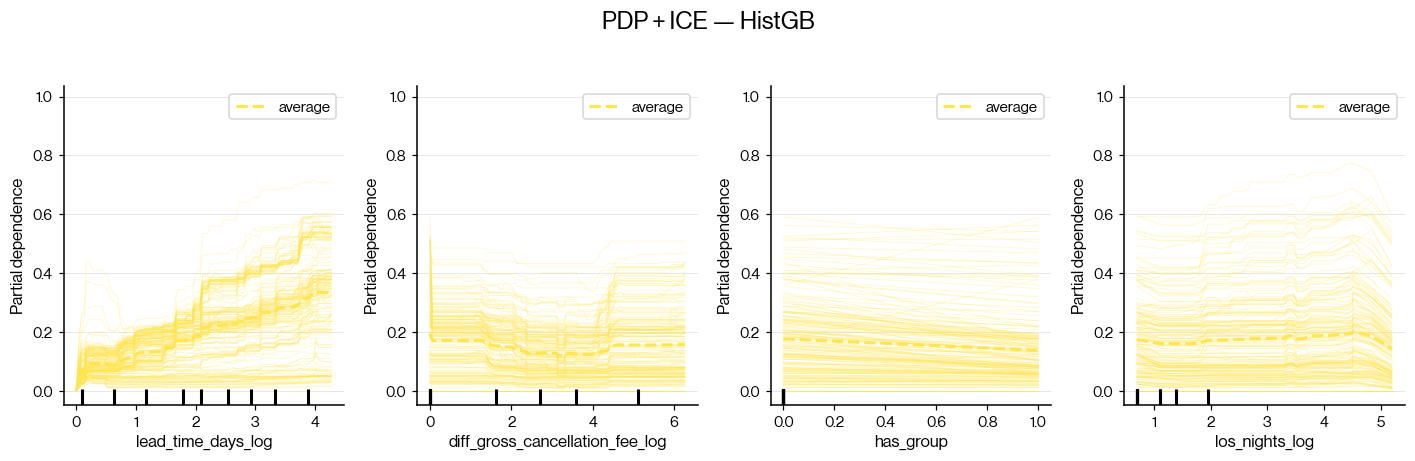

 98%|===================| 780/800 [00:11<00:00]       

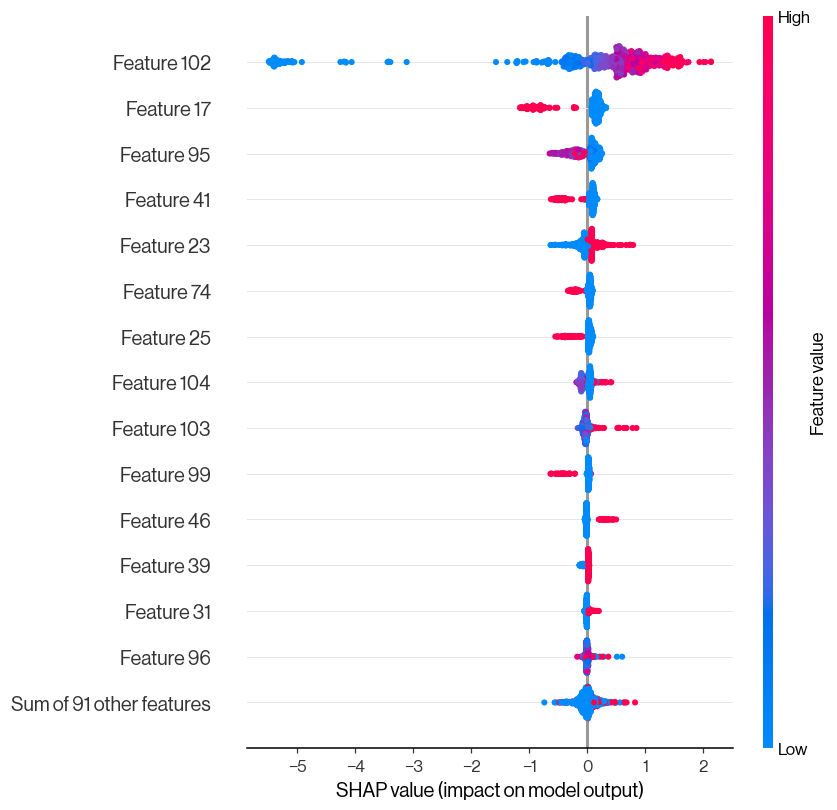

In [ ]:
# =============================================================================
# §11b PDP + (optional) SHAP - as static PNG (no clean Plotly equivalent)
# =============================================================================
from sklearn.inspection import PartialDependenceDisplay
top_num = [f for f in perm_df["parent"] if f in NUM_FEATURES][:4]   # most important numeric
fig, axes = plt.subplots(1, len(top_num), figsize=(13, 4))
PartialDependenceDisplay.from_estimator(model, X_val.sample(min(1000, len(X_val)), random_state=SEED),
                                        features=top_num, kind="both", subsample=200,
                                        random_state=SEED, ax=axes)
fig.suptitle("PDP + ICE - HistGB", y=1.04); fig.tight_layout()
fig.savefig(FIG / "11_pdp_ice.png", dpi=150, bbox_inches="tight"); plt.show()

# SHAP optional: TreeExplainer does not always support HistGB -> try defensively.
try:
    import shap
    _Xs = X_val.sample(min(800, len(X_val)), random_state=SEED)
    _base = model.named_steps["clf"].calibrated_classifiers_[0].estimator   # uncalibrated HistGB
    _Xenc = model.named_steps["prep"].transform(_Xs)
    _Xd = (_Xenc.toarray() if hasattr(_Xenc, "toarray") else np.asarray(_Xenc))
    expl = shap.Explainer(_base, _Xd)
    sv = expl(_Xd)
    shap.plots.beeswarm(sv, max_display=15, show=False)
    plt.gcf().tight_layout(); plt.gcf().savefig(FIG / "11_shap_beeswarm.png", dpi=150, bbox_inches="tight"); plt.show()
except Exception as e:
    print(f"SHAP skipped ({type(e).__name__}: {e}); permutation importance is sufficient as XAI.")

## §12 - Save artifacts (convention → 05 + Dash recognize it automatically)

In [15]:
# =============================================================================
# §12 PERSIST  (same convention as 01/02)
# =============================================================================
import joblib, sklearn
from src import data_dir

# (1) Complete pipeline -> loaded by src.scoring.load_model("histgb").
joblib.dump(model, data_dir() / "03_histgb_model.joblib")

# (2) Val+test predictions (block-separated) -> 05 reads them via glob.
_ctx = ["arrival", "property_name", "lead_time_days", "temporal_split"]
pred_val = df.loc[m_val, _ctx].copy();  pred_val["y_true"], pred_val["y_prob"] = y_val.values, prob_val
pred_test = df.loc[m_test, _ctx].copy(); pred_test["y_true"], pred_test["y_prob"] = y_test.values, prob_test
pd.concat([pred_val, pred_test]).to_parquet(data_dir() / "03_histgb_predictions.parquet")

# (3) Model card (same schema as 01/02 -> Dash model page + best_model_by_auc).
model_card = {
    "model": "histgb_onehot_isotonic", "notebook": "03_histgb.ipynb",
    "trained_at": pd.Timestamp.now(tz="UTC").isoformat(), "sklearn_version": sklearn.__version__,
    "fast_dev": FAST_DEV, "n_train": int(len(X_train)), "n_val": int(len(X_val)), "n_test": int(len(X_test)),
    "features_numeric": NUM_FEATURES + NUM_HISTORY, "features_categorical": CAT_FEATURES,
    "encoding": "onehot (cat) + passthrough (num, NaN native)",
    "hyperparams": {**HGB_FIXED, **FINAL_PARAMS, "calibration": "isotonic_cv5"},
    "tuning": {"selected": "tuned" if FINAL_PARAMS is not BASE_PARAMS else "baseline",
               "search_n_iter": int(N_SEARCH), "best_cv_ap": float(search.best_score_)},
    "val_metrics": val_metrics.to_dict(), "test_metrics": test_metrics.to_dict(),
    "operating_points": op_points.to_dict(orient="records"),
}
(TAB / "model_card.json").write_text(json.dumps(model_card, indent=2, default=str))
print("Saved: 03_histgb_model.joblib, 03_histgb_predictions.parquet, model_card.json, importances.")
print(f"Test AUC = {test_metrics['auc']:.4f} | AP = {test_metrics['ap']:.4f} | Brier = {test_metrics['brier']:.4f}")

Saved: 03_histgb_model.joblib, 03_histgb_predictions.parquet, model_card.json, importances.
Test AUC = 0.7868 | AP = 0.4489 | Brier = 0.1201


## §13 - Conclusion

HistGradientBoosting following the identical template to 01/02 (roster + PIT split +
calibration + threshold on val). Artifacts follow the naming convention →
`05_model_comparison` pulls the predictions automatically, and the Dash app shows
the model in the dropdown "HistGradientBoosting (03)" including model card metrics,
ROC/PR/calibration and permutation importance. **No dashboard code needed.**

## §13 Walk-forward evaluation + deployment model (v11)

Routes the PRODUCTION model and its honest forward metrics through `src.training` — the identical code the dash app's retrain buttons call. The single-split sections above remain as per-model diagnostics/XAI; the joblib written here (on **all resolved data**) is the one served. `mode="retune"` re-searches hyperparameters; the app uses `mode="refit"` for routine retrains. Heavy step — expect several minutes.

In [ ]:
# Walk-forward evaluation + DEPLOYMENT fit via src.training (the same path the dash app
# calls). Honest one-step-ahead metrics (the PROCEDURE), then a model fit on ALL resolved
# data. This supersedes the single-split joblib persisted above as the PRODUCTION model.
import src.training as T
MODEL = "histgb"

# mode="retune" establishes/refreshes hyperparameters; routine app retrains use "refit".
deploy = T.retrain(MODEL, mode="retune")

import pandas as pd
display(pd.DataFrame(deploy["walk_forward"]["per_fold"]))
print("walk-forward aggregate (mean ± std):")
for _m, _v in deploy["walk_forward"]["aggregate"].items():
    print(f"  {_m:6s} {_v['mean']:.4f} ± {_v['std']:.4f}")
print("\ndeployment model persisted ->", deploy["persisted"]["joblib"])
print("trained on", deploy["n_train_deploy"], "resolved rows | feature_change:",
      deploy["feature_change"]["changed"], deploy["feature_change"]["added"] or "")